In [570]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [571]:
df = pd.read_csv("Bengaluru_House_Data.csv")

In [572]:
df.head(10)

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00
5,Super built-up Area,Ready To Move,Whitefield,2 BHK,DuenaTa,1170,2.0,1.0,38.00
6,Super built-up Area,18-May,Old Airport Road,4 BHK,Jaades,2732,4.0,NaN,204.00
7,Super built-up Area,Ready To Move,Rajaji Nagar,4 BHK,Brway G,3300,4.0,NaN,600.00
8,Super built-up Area,Ready To Move,Marathahalli,3 BHK,NaN,1310,3.0,1.0,63.25
9,Plot Area,Ready To Move,Gandhi Bazar,6 Bedroom,NaN,1020,6.0,NaN,370.00


In [573]:
df.tail(10)

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
13310,Super built-up Area,Ready To Move,Rachenahalli,2 BHK,NaN,1050,2.0,2.0,52.71
13311,Plot Area,Ready To Move,Ramamurthy Nagar,7 Bedroom,NaN,1500,9.0,2.0,250.00
13312,Super built-up Area,Ready To Move,Bellandur,2 BHK,NaN,1262,2.0,2.0,47.00
13313,Super built-up Area,Ready To Move,Uttarahalli,3 BHK,Aklia R,1345,2.0,1.0,57.00
13314,Super built-up Area,Ready To Move,Green Glen Layout,3 BHK,SoosePr,1715,3.0,3.0,112.00
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453,4.0,0.0,231.00
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,NaN,3600,5.0,NaN,400.00
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141,2.0,1.0,60.00
13318,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,SollyCl,4689,4.0,1.0,488.00
13319,Super built-up Area,Ready To Move,Doddathoguru,1 BHK,NaN,550,1.0,1.0,17.00


In [574]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  str    
 1   availability  13320 non-null  str    
 2   location      13319 non-null  str    
 3   size          13304 non-null  str    
 4   society       7818 non-null   str    
 5   total_sqft    13320 non-null  str    
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), str(6)
memory usage: 936.7 KB


In [575]:
df=df.drop_duplicates()


In [576]:
df.isnull().sum()

area_type          0
availability       0
location           1
size              16
society         5328
total_sqft         0
bath              73
balcony          605
price              0
dtype: int64

In [577]:
df["area_type"].value_counts()

area_type
Super built-up  Area    8317
Built-up  Area          2398
Plot  Area              1989
Carpet  Area              87
Name: count, dtype: int64

In [578]:
df["availability"].value_counts()

availability
Ready To Move    10172
18-May             292
18-Dec             284
18-Apr             269
18-Aug             187
                 ...  
15-Aug               1
17-Jan               1
16-Nov               1
16-Jan               1
14-Jul               1
Name: count, Length: 81, dtype: int64

In [579]:
df["location"].value_counts()

location
Whitefield                                         523
Sarjapur  Road                                     379
Electronic City                                    287
Kanakpura Road                                     249
Thanisandra                                        229
                                                  ... 
Pattegarhpalya                                       1
Tilak Nagar                                          1
12th cross srinivas nagar banshankari 3rd stage      1
Havanur extension                                    1
Abshot Layout                                        1
Name: count, Length: 1305, dtype: int64

In [580]:
df["location"].nunique()

1305

In [581]:
df["size"]=df["size"].str.replace("Bedroom","BHK",regex=False)

In [582]:
df["size"].isna().sum()


np.int64(16)

In [583]:
df.loc[df["size"].isna()]


,area_type,availability,location,size,society,total_sqft,bath,balcony,price
579,Plot Area,Immediate Possession,Sarjapur Road,NaN,Asiss B,1200 - 2400,NaN,NaN,34.185
1775,Plot Area,Immediate Possession,IVC Road,NaN,Orana N,2000 - 5634,NaN,NaN,124.000
2264,Plot Area,Immediate Possession,Banashankari,NaN,NaN,2400,NaN,NaN,460.000
2809,Plot Area,Immediate Possession,Sarjapur Road,NaN,AsdiaAr,1200 - 2400,NaN,NaN,28.785
2862,Plot Area,Immediate Possession,Devanahalli,NaN,Ajleyor,1500 - 2400,NaN,NaN,46.800
5333,Plot Area,Immediate Possession,Devanahalli,NaN,Emngs S,2100 - 5405,NaN,NaN,177.115
6423,Plot Area,Immediate Possession,Whitefield,NaN,SRniaGa,2324,NaN,NaN,26.730
6636,Plot Area,Immediate Possession,Jigani,NaN,S2enste,1500,NaN,NaN,25.490
6719,Plot Area,Immediate Possession,Hoskote,NaN,SJowsn,800 - 2660,NaN,NaN,28.545
7680,Plot Area,Immediate Possession,Kasavanhalli,NaN,NaN,5000,NaN,NaN,400.000


In [584]:
df = df[df["size"].notna()]


In [585]:
df["size"].isna().sum()


np.int64(0)

In [586]:
def extract_bhk_components(x):
    cols = ["bedrooms", "halls", "kitchens"]
    if pd.isna(x):
        return pd.Series([np.nan] * 3, index=cols)
    parts = str(x).strip().split()
    if not parts:
        return pd.Series([np.nan] * 3, index=cols)
    num = pd.to_numeric(parts[0], errors="coerce")
    unit = " ".join(parts[1:]).lower()
    if "rk" in unit:
        values = [0, 0, 1]
    elif any(k in unit for k in ["bhk", "bedroom"]):
        values = [num, 1, 1]
    else:
        values = [num, np.nan, np.nan]
    return pd.Series(values, index=cols)

In [587]:
df[["bedrooms", "halls", "kitchens"]] = df["size"].apply(extract_bhk_components)
df

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,bedrooms,halls,kitchens
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07,2,1,1
1,Plot Area,Ready To Move,Chikka Tirupathi,4 BHK,Theanmp,2600,5.0,3.0,120.00,4,1,1
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00,3,1,1
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00,3,1,1
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00,2,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
13314,Super built-up Area,Ready To Move,Green Glen Layout,3 BHK,SoosePr,1715,3.0,3.0,112.00,3,1,1
13315,Built-up Area,Ready To Move,Whitefield,5 BHK,ArsiaEx,3453,4.0,0.0,231.00,5,1,1
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,NaN,3600,5.0,NaN,400.00,4,1,1
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141,2.0,1.0,60.00,2,1,1


In [589]:
df["balcony"] = df["balcony"].fillna(df["balcony"].mode())

In [590]:
df.isna().sum()


area_type          0
availability       0
location           1
size               0
society         5325
total_sqft         0
bath              57
balcony            0
price              0
bedrooms           0
halls              0
kitchens           0
dtype: int64

In [591]:
df.loc[df["bath"].isna()]


,area_type,availability,location,size,society,total_sqft,bath,balcony,price,bedrooms,halls,kitchens
56,Built-up Area,20-Feb,Devanahalli,4 BHK,BrereAt,3010 - 3410,NaN,2.0,192.000,4,1,1
81,Built-up Area,18-Oct,Hennur Road,4 BHK,Gollela,2957 - 3450,NaN,2.0,224.500,4,1,1
224,Super built-up Area,19-Dec,Devanahalli,3 BHK,Jurdsig,1520 - 1740,NaN,2.0,74.820,3,1,1
344,Super built-up Area,21-Dec,Kanakpura Road,1 BHK,PrarePa,525,NaN,2.0,21.530,1,1,1
669,Super built-up Area,18-Dec,JP Nagar,5 BHK,Pehtsa,4400 - 6640,NaN,2.0,375.000,5,1,1
702,Super built-up Area,18-Dec,JP Nagar,5 BHK,Pehtsa,4400 - 6800,NaN,2.0,548.500,5,1,1
801,Super built-up Area,18-Dec,JP Nagar,4 BHK,Pehtsa,4000 - 5249,NaN,2.0,453.000,4,1,1
941,Super built-up Area,Ready To Move,Whitefield,4 BHK,PrOakSi,3606 - 5091,NaN,2.0,304.000,4,1,1
1264,Built-up Area,18-May,Hennur,3 BHK,Asoilul,2264,NaN,2.0,155.000,3,1,1
1267,Super built-up Area,18-Jun,Yelahanka,3 BHK,Shalkri,1440 - 1884,NaN,2.0,67.980,3,1,1


In [594]:
df["bath"] = df["bath"].fillna(df.groupby("size")["bath"].transform("median"))


In [595]:
df["bath"].isna().sum()


np.int64(0)

In [596]:
df.loc[df["location"].isna()]


,area_type,availability,location,size,society,total_sqft,bath,balcony,price,bedrooms,halls,kitchens
568,Super built-up Area,Ready To Move,NaN,3 BHK,Grare S,1600,3.0,2.0,86.0,3,1,1


In [597]:
df.loc[df["society"]=="Grare S"]


,area_type,availability,location,size,society,total_sqft,bath,balcony,price,bedrooms,halls,kitchens
568,Super built-up Area,Ready To Move,NaN,3 BHK,Grare S,1600,3.0,2.0,86.0,3,1,1
12238,Carpet Area,Ready To Move,Anantapura,3 BHK,Grare S,1600,3.0,2.0,77.0,3,1,1


In [598]:
df["location"]=df["location"].fillna("Anantapura")

In [599]:
df["location"].isnull().sum()

np.int64(0)

In [600]:
df.isna().sum()

area_type          0
availability       0
location           0
size               0
society         5325
total_sqft         0
bath               0
balcony            0
price              0
bedrooms           0
halls              0
kitchens           0
dtype: int64

In [601]:
df=df.drop("size",axis=1)


In [602]:
df["society"].isna().sum()/len(df)


np.float64(0.41682974559686886)

In [603]:
society_mode = df.groupby("location")["society"].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
)


In [604]:
df["society"] = df["society"].fillna(df["location"].map(society_mode))


In [605]:
df["society"].isna().sum()


np.int64(1385)

In [606]:
df["society"] = df["society"].fillna("unknown")


In [607]:
df["society"].isna().sum()


np.int64(0)

In [608]:
df.isna().sum()


area_type       0
availability    0
location        0
society         0
total_sqft      0
bath            0
balcony         0
price           0
bedrooms        0
halls           0
kitchens        0
dtype: int64

In [609]:
df["total_sqft"].value_counts()


total_sqft
1200           808
1100           210
1500           201
2400           195
600            178
              ... 
1020 - 1130      1
2758             1
1133 - 1384      1
774              1
4689             1
Name: count, Length: 2110, dtype: int64

In [610]:
def clean_total_sqft(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    if "perch" in x.lower():
        num_str = x.lower().replace("perch", "").strip()
        return pd.to_numeric(num_str) * 272.25
    if "sq. yards" in x.lower():
        num_str = x.lower().replace("sq. yards", "").strip()
        return pd.to_numeric(num_str) * 9.0
    if "acre" in x.lower():
        num_str = x.lower().replace("acres", "").replace("acre", "").strip()
        return pd.to_numeric(num_str) * 43560.0
    if "sq. meter" in x.lower():
        num_str = x.lower().replace("sq. meter", "").strip()
        return pd.to_numeric(num_str) * 10.7639
    if "cent" in x.lower():
        num_str = x.lower().replace("cents", "").replace("cent", "").strip()
        return pd.to_numeric(num_str) * 435.6
    if "ground" in x.lower():
        num_str = x.lower().replace("grounds", "").replace("ground", "").strip()
        return pd.to_numeric(num_str) * 2400.0
    if "guntha" in x.lower():
        num_str = x.lower().replace("guntha", "").strip()
        return pd.to_numeric(num_str) * 1089.0
    if "-" in x:
        parts = x.split("-")
        a1 = pd.to_numeric(parts[0].strip())
        a2 = pd.to_numeric(parts[1].strip())
        return (a1 + a2) / 2.0
    return pd.to_numeric(x)



In [611]:
df["total_sqft"] = df["total_sqft"].apply(clean_total_sqft)


In [612]:
df["total_sqft"].value_counts()


total_sqft
1200.0    808
1100.0    210
1500.0    201
2400.0    196
600.0     178
         ... 
2395.0      1
2758.0      1
1258.5      1
774.0       1
4689.0      1
Name: count, Length: 2031, dtype: int64

In [613]:
df["balcony"] = df["balcony"].fillna(df["balcony"].mode())

In [614]:
df.isna().sum()


area_type       0
availability    0
location        0
society         0
total_sqft      0
bath            0
balcony         0
price           0
bedrooms        0
halls           0
kitchens        0
dtype: int64

In [615]:
df

,area_type,availability,location,society,total_sqft,bath,balcony,price,bedrooms,halls,kitchens
0,Super built-up Area,19-Dec,Electronic City Phase II,Coomee,1056.0,2.0,1.0,39.07,2,1,1
1,Plot Area,Ready To Move,Chikka Tirupathi,Theanmp,2600.0,5.0,3.0,120.00,4,1,1
2,Built-up Area,Ready To Move,Uttarahalli,Aklia R,1440.0,2.0,3.0,62.00,3,1,1
3,Super built-up Area,Ready To Move,Lingadheeranahalli,Soiewre,1521.0,3.0,1.0,95.00,3,1,1
4,Super built-up Area,Ready To Move,Kothanur,Somumys,1200.0,2.0,1.0,51.00,2,1,1
...,...,...,...,...,...,...,...,...,...,...,...
13314,Super built-up Area,Ready To Move,Green Glen Layout,SoosePr,1715.0,3.0,3.0,112.00,3,1,1
13315,Built-up Area,Ready To Move,Whitefield,ArsiaEx,3453.0,4.0,0.0,231.00,5,1,1
13316,Super built-up Area,Ready To Move,Richards Town,Alnorrm,3600.0,5.0,2.0,400.00,4,1,1
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,Mahla T,1141.0,2.0,1.0,60.00,2,1,1


In [616]:
df["availability"].value_counts()


availability
Ready To Move    10172
18-May             292
18-Dec             284
18-Apr             269
18-Aug             187
                 ...  
15-Aug               1
17-Jan               1
16-Nov               1
16-Jan               1
14-Jul               1
Name: count, Length: 80, dtype: int64

In [617]:
df["availability"] = np.where(df["availability"].str.strip().isin(["Ready To Move", "Immediate Possession"]),"Ready", "Soon")


In [618]:
df["availability"]


0         Soon
1        Ready
2        Ready
3        Ready
4        Ready
         ...  
13314    Ready
13315    Ready
13316    Ready
13317    Ready
13318     Soon
Name: availability, Length: 12775, dtype: str

In [619]:
num_cols=['total_sqft', 'bath', 'balcony', 'price','bedrooms', 'halls','kitchens']
text_cols=['area_type', 'availability', 'location', 'society']



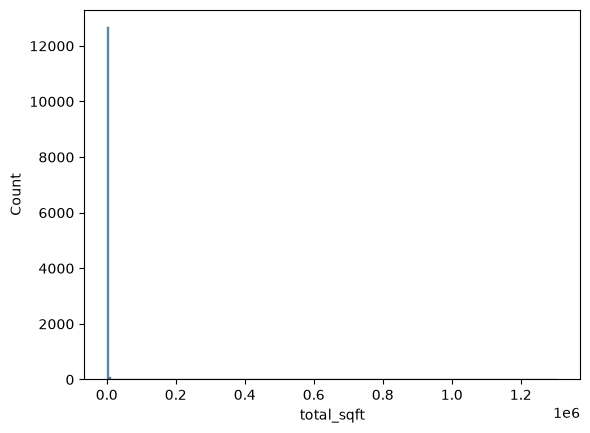

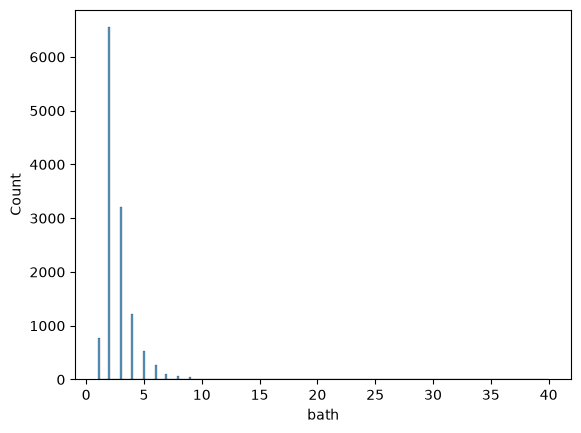

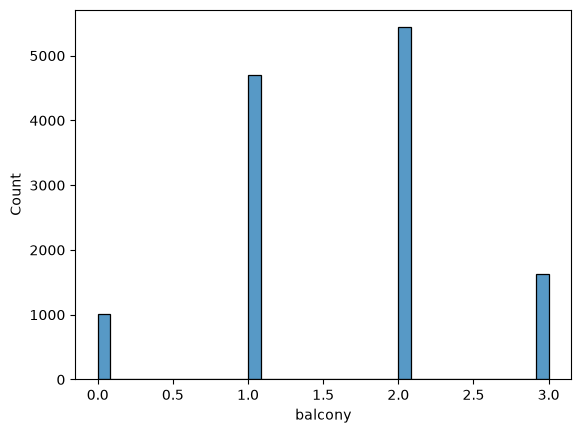

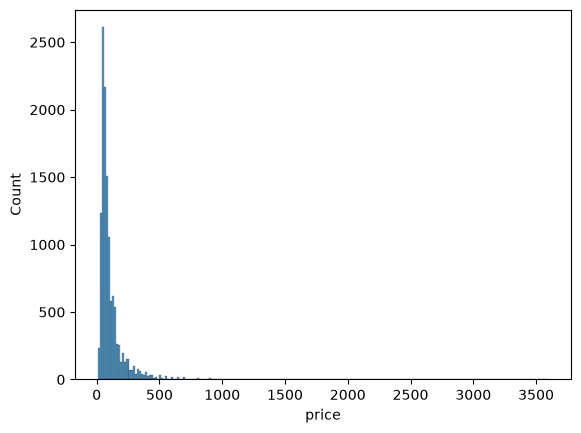

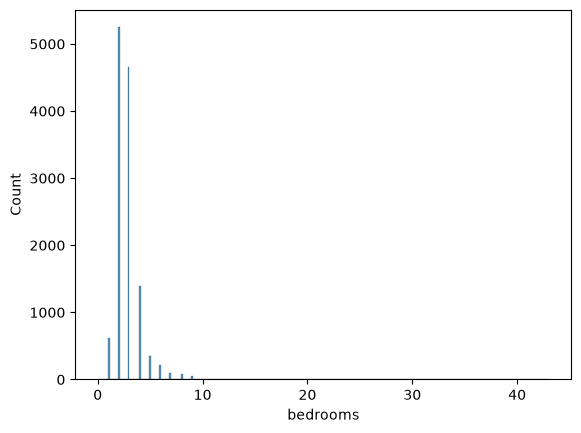

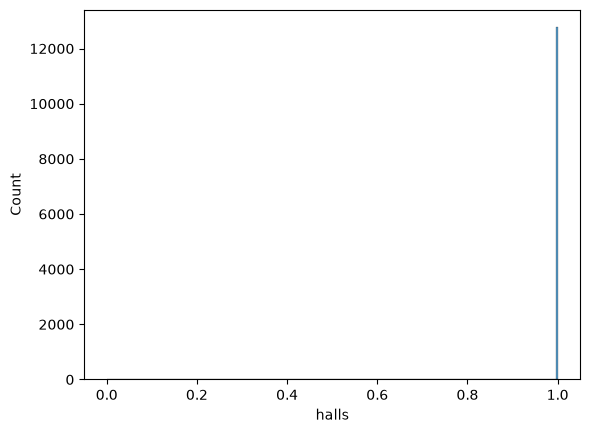

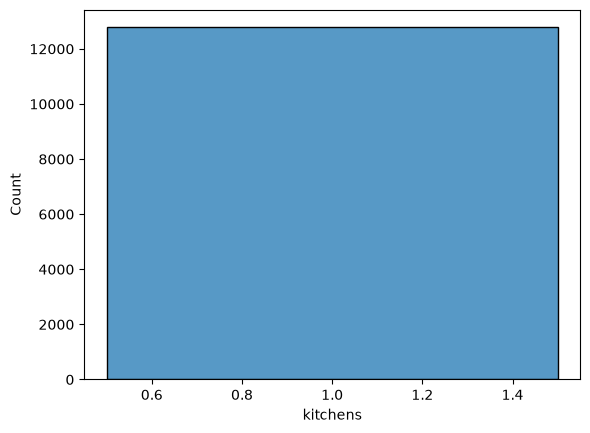

In [620]:
for i in num_cols:
    plt.figure()
    sns.histplot(df[i])


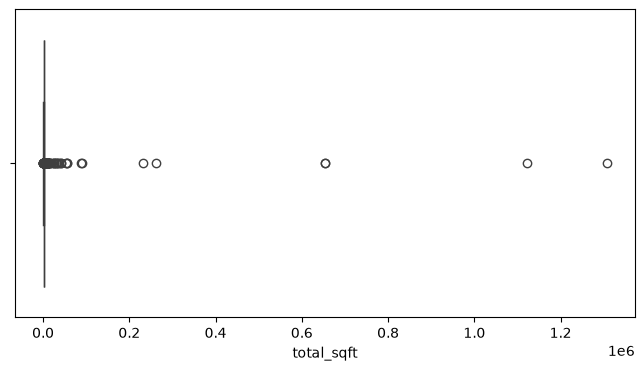

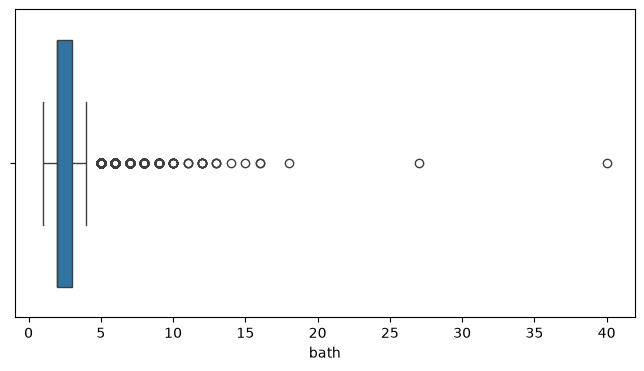

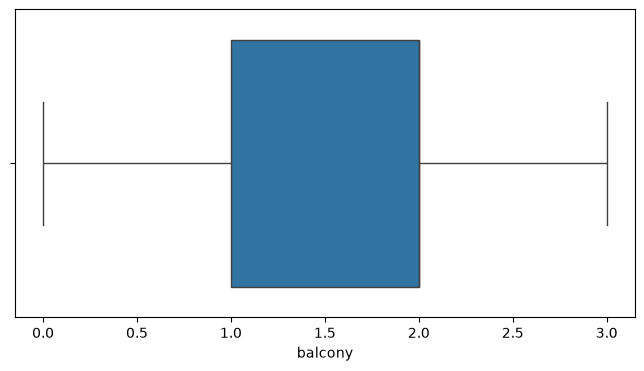

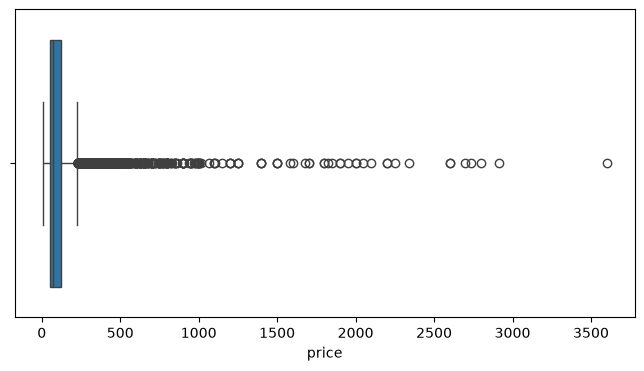

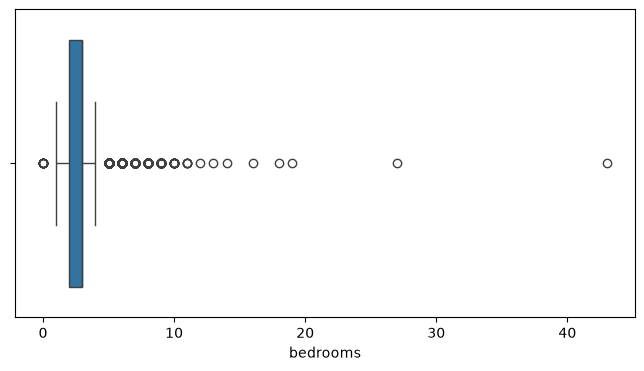

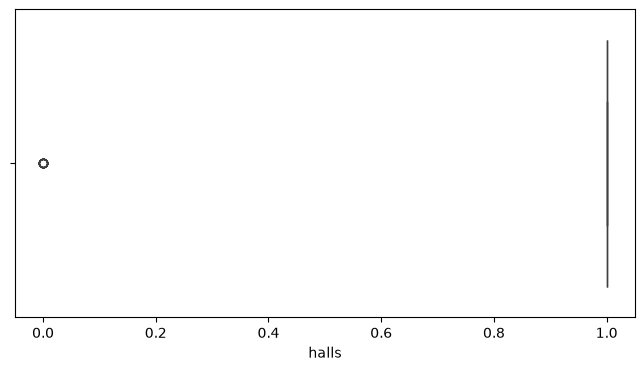

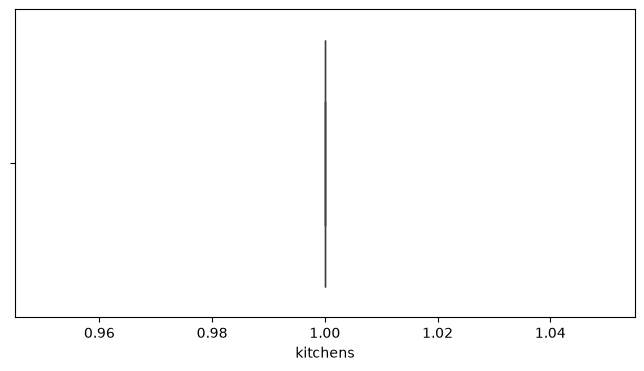

In [621]:
for i in num_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[i])
    plt.show()

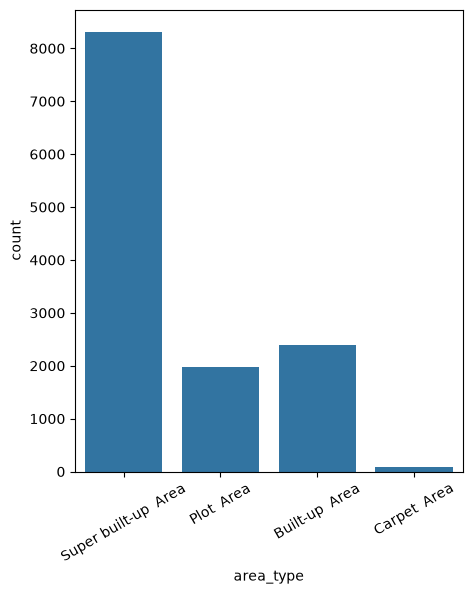

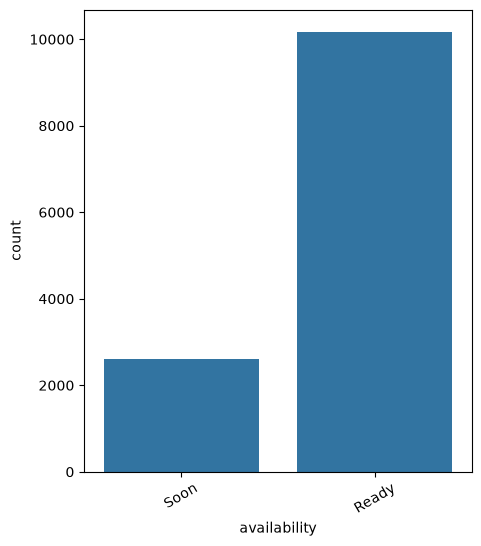

In [622]:
for c in ['area_type', 'availability']:
    plt.figure(figsize=(5,6))
    sns.countplot(x=df[c])
    plt.xticks(rotation=30)
    plt.show()

# Sqft vs Price Distribution

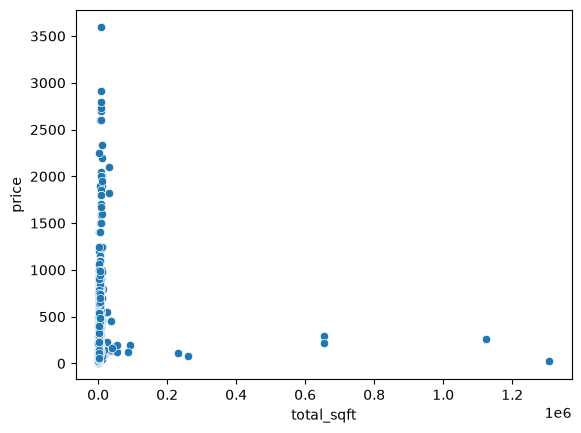

In [623]:
sns.scatterplot(data=df,x="total_sqft",y="price")
plt.show()


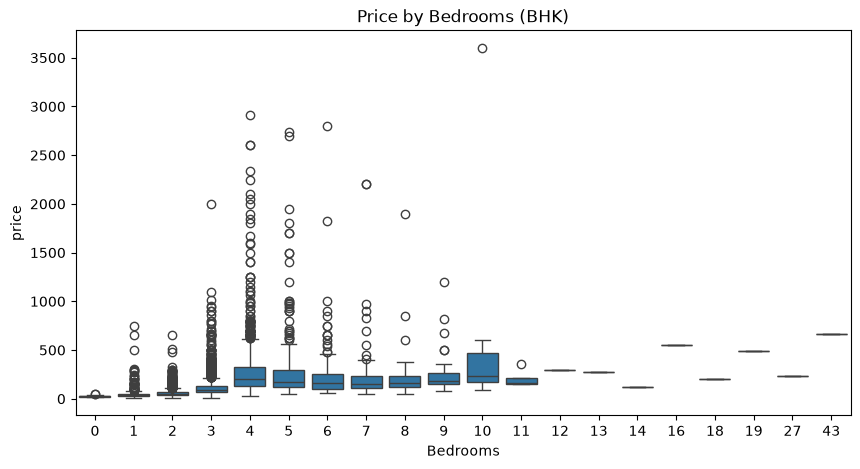

In [624]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="bedrooms", y="price")
plt.title("Price by Bedrooms (BHK)")
plt.xlabel("Bedrooms")
plt.show()

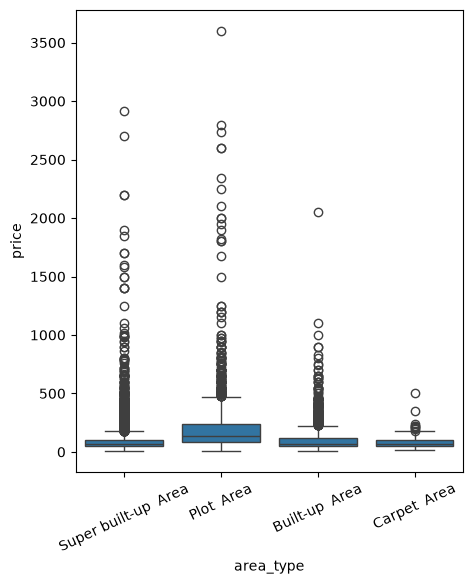

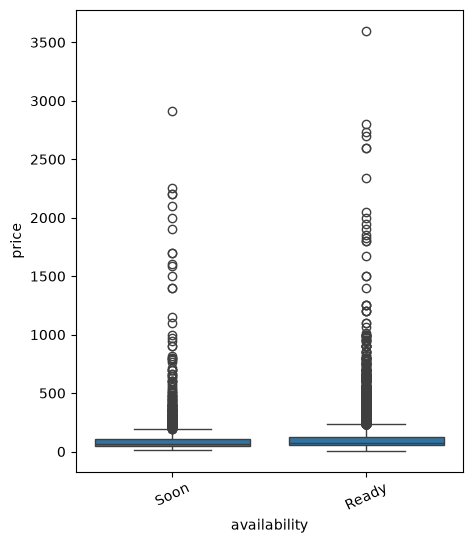

In [625]:
for col in ['area_type', 'availability']:
    plt.figure(figsize=(5,6))
    sns.boxplot(data=df, x=col, y="price")
    plt.xticks(rotation=25)
    plt.show()

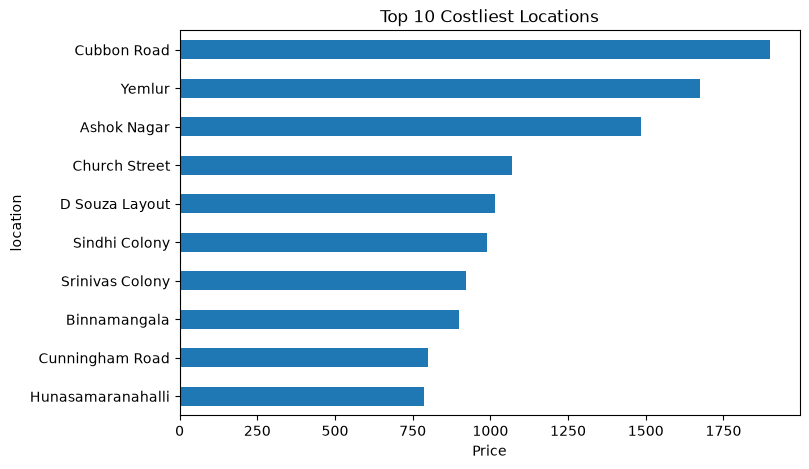

In [626]:
top = df[df["location"] != "other"].groupby("location")["price"].median().nlargest(10)
top.sort_values().plot(kind="barh", figsize=(8, 5))
plt.title("Top 10 Costliest Locations")
plt.xlabel("Price")
plt.show()

In [627]:
def find_outliers(series):
    q1, q3 = series.quantile([0.25, 0.75])
    spread = q3 - q1
    lower_limit = q1 - 1.5 * spread
    upper_limit = q3 + 1.5 * spread
    is_outlier = ~series.between(lower_limit, upper_limit)
    return {
        "lower": lower_limit,
        "upper": upper_limit,
        "count": is_outlier.sum(),
    }

In [628]:
num_col = ["total_sqft", "bath", "balcony", "price", "bedrooms","halls","kitchens"]
rows = []
for col in num_col:
    res = find_outliers(df[col])
    rows.append([col, res["lower"], res["upper"], res["count"]])
outlier_report = pd.DataFrame(
    rows, columns=["column", "lower_limit", "upper_limit", "outlier_count"]
)
outlier_report

,column,lower_limit,upper_limit,outlier_count
0,total_sqft,210.5,2582.5,1161
1,bath,0.5,4.5,1035
2,balcony,-0.5,3.5,0
3,price,-56.5,227.5,1255
4,bedrooms,0.5,4.5,852
5,halls,1.0,1.0,13
6,kitchens,1.0,1.0,0


In [629]:
df[df["bedrooms"] > 10][["bedrooms", "price", "total_sqft", "location"]]

,bedrooms,price,total_sqft,location
459,11,360.0,5000.0,1 Giri Nagar
1718,27,230.0,8000.0,2Electronic City Phase II
1768,11,170.0,1200.0,1 Ramamurthy Nagar
3379,19,490.0,2000.0,1Hanuman Nagar
3609,16,550.0,10000.0,Koramangala Industrial Layout
3853,11,150.0,1200.0,1 Annasandrapalya
4684,43,660.0,2400.0,Munnekollal
4916,14,125.0,1250.0,1Channasandra
6533,12,300.0,2232.0,Mysore Road
7979,11,150.0,6000.0,1 Immadihalli


In [630]:
print("Rows before:", len(df))
sqft_per_bedroom = df["total_sqft"] / df["bedrooms"].clip(lower=1) >= 300
bath_ok = df["bath"] <= df["bedrooms"] + 2
sqft_ok = df["total_sqft"] <= 8000
rate_ok = (df["price"] * 100000 / df["total_sqft"]).between(2000, 25000)
df = df[sqft_per_bedroom & bath_ok & sqft_ok & rate_ok]
print("Rows after:", len(df))

Rows before: 12775
Rows after: 11881


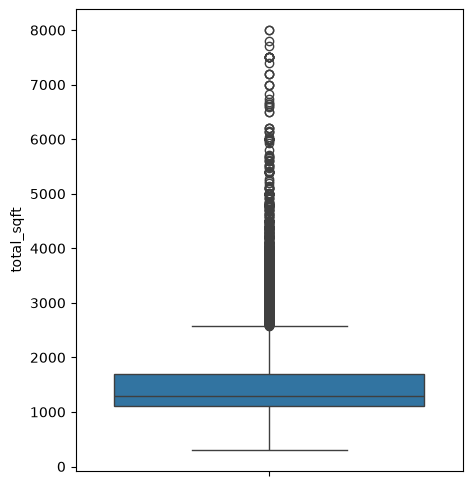

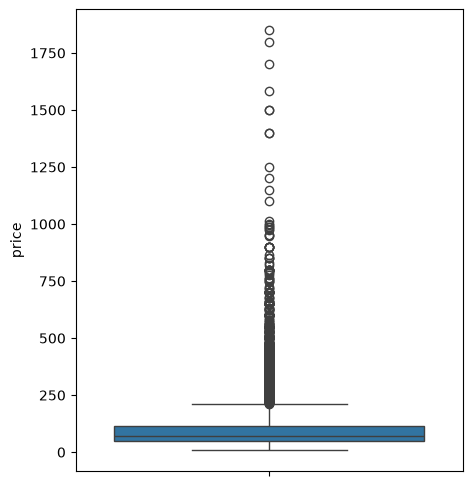

In [631]:
for i in ["total_sqft","price"]:
    plt.figure(figsize=(5,6))
    sns.boxplot(df[i])


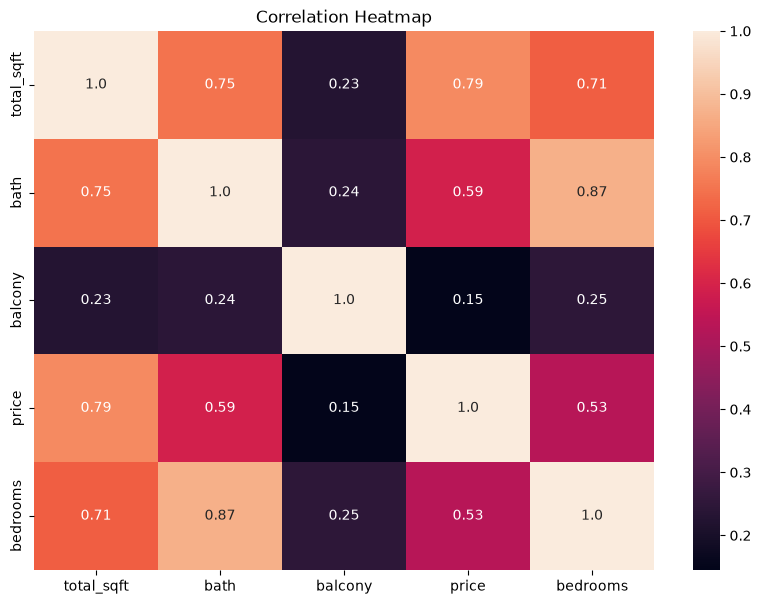

In [632]:
plt.figure(figsize=(10, 7))
sns.heatmap(df[["total_sqft", "bath", "balcony", "price", "bedrooms"]].corr(),annot=True,fmt=".2")
plt.title("Correlation Heatmap")
plt.show()

In [633]:
df["area_type"].value_counts()


area_type
Super built-up  Area    8234
Built-up  Area          2309
Plot  Area              1256
Carpet  Area              82
Name: count, dtype: int64

In [635]:
df["location"].nunique()


1200

In [636]:
df["location"] = df["location"].str.strip()
df["location"].nunique()


1190

In [637]:
df["location"].value_counts().describe()


count    1190.000000
mean        9.984034
std        28.670347
min         1.000000
25%         1.000000
50%         2.500000
75%         7.000000
max       518.000000
Name: count, dtype: float64

In [638]:
df

,area_type,availability,location,society,total_sqft,bath,balcony,price,bedrooms,halls,kitchens
0,Super built-up Area,Soon,Electronic City Phase II,Coomee,1056.0,2.0,1.0,39.07,2,1,1
1,Plot Area,Ready,Chikka Tirupathi,Theanmp,2600.0,5.0,3.0,120.00,4,1,1
2,Built-up Area,Ready,Uttarahalli,Aklia R,1440.0,2.0,3.0,62.00,3,1,1
3,Super built-up Area,Ready,Lingadheeranahalli,Soiewre,1521.0,3.0,1.0,95.00,3,1,1
4,Super built-up Area,Ready,Kothanur,Somumys,1200.0,2.0,1.0,51.00,2,1,1
...,...,...,...,...,...,...,...,...,...,...,...
13314,Super built-up Area,Ready,Green Glen Layout,SoosePr,1715.0,3.0,3.0,112.00,3,1,1
13315,Built-up Area,Ready,Whitefield,ArsiaEx,3453.0,4.0,0.0,231.00,5,1,1
13316,Super built-up Area,Ready,Richards Town,Alnorrm,3600.0,5.0,2.0,400.00,4,1,1
13317,Built-up Area,Ready,Raja Rajeshwari Nagar,Mahla T,1141.0,2.0,1.0,60.00,2,1,1


In [656]:
model_df=df[["bedrooms", "halls", "kitchens","location","price","bath","total_sqft","balcony"]].copy()


In [657]:
model_df = pd.get_dummies(model_df, columns=["location"], drop_first=True)

In [658]:
X = model_df.drop("price", axis=1)
y = model_df["price"]

In [659]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

In [660]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1195,)","[-12.55, -8.69, -0. ,..., -8.73,111.73,-26.57]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1195,)","['bedrooms','halls','kitchens',...,'location_tc.palya', 'location_white field,kadugodi','location_whitefiled']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-15.97
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1195
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1090)


In [661]:
y_pred = model.predict(X_test)

In [662]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("R2 Score:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

R2 Score: 0.702236159712297
MAE: 32.42792015896437
RMSE: 61.4128726975438


In [663]:
comparison = pd.DataFrame({"Actual Price": y_test.values,"Predicted Price": y_pred})
comparison.head(10)

,Actual Price,Predicted Price
0,150.00,111.170864
1,220.00,262.557514
2,125.00,195.588899
3,180.00,83.200424
4,47.74,84.002074
5,153.00,161.115954
6,77.00,118.053298
7,345.00,345.003885
8,35.00,8.150899
9,59.00,60.762098
